Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\한민규/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:11<00:00, 8.63MB/s]


--- 예측 결과 ---
Top 1: 클래스 ID 258, 확률 87.33%
Top 2: 클래스 ID 259, 확률 3.03%
Top 3: 클래스 ID 270, 확률 1.97%
Top 4: 클래스 ID 261, 확률 1.11%
Top 5: 클래스 ID 248, 확률 0.92%


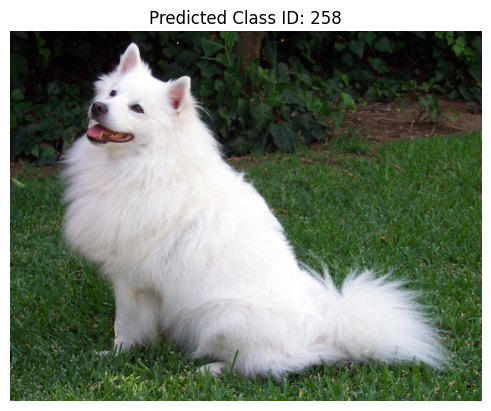

In [ ]:
#기존에 있던 결과값 가져오기
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# 1. 사전 학습된 ResNet-50 모델 불러오기
# ImageNet-1K 데이터셋으로 이미 학습된 가중치를 사용합니다.
model = models.resnet50(weights='IMAGENET1K_V1')
model.eval()  # 추론 모드로 설정 (배치 정규화 등이 고정됨)

# 2. 이미지 전처리 설정
# ResNet은 입력 이미지 크기를 224x224로 요구합니다[cite: 206].
preprocess = transforms.Compose([
    transforms.Resize(256),                  # 짧은 쪽을 256으로 리사이즈
    transforms.CenterCrop(224),              # 중앙을 224x224로 크롭 [cite: 206]
    transforms.ToTensor(),                   # 0~1 사이의 텐서로 변환
    transforms.Normalize(                    # ImageNet 표준 평균 및 표준편차로 정규화
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# 3. 테스트용 이미지 다운로드 (예: 골든 리트리버)
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# 4. 이미지 전처리 적용 및 배치 차원 추가
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)  # (3, 224, 224) -> (1, 3, 224, 224)

# 5. GPU 사용 가능 시 GPU로 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
input_batch = input_batch.to(device)

# 6. 추론(Inference) 수행
with torch.no_grad():  # 기울기 계산 비활성화 (메모리 절약)
    output = model(input_batch)

# 7. 결과 해석 (확률로 변환)
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# 8. ImageNet 클래스 라벨(1,000개) 다운로드 및 확인
# 실제 서비스에서는 별도의 txt 파일을 로드하여 매칭합니다.
# 상위 5개 결과 출력
top5_prob, top5_catid = torch.topk(probabilities, 5)

print("--- 예측 결과 ---")
for i in range(top5_prob.size(0)):
    print(f"Top {i+1}: 클래스 ID {top5_catid[i].item()}, 확률 {top5_prob[i].item()*100:.2f}%")

# 9. 이미지 시각화
plt.imshow(img)
plt.title(f"Predicted Class ID: {top5_catid[0].item()}")
plt.axis('off')
plt.show()

In [9]:
#실제로 돌려보기
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import copy

# 1. 환경 설정
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 데이터 경로 (30개 폴더만 남긴 경로)
data_dir = r'C:\Users\한민규\Desktop\머신러닝 실습\data\Flowers30' 

# 3. 전처리 (30개 정도면 약간의 변형을 줘도 학습이 잘 됩니다)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 4. 데이터 로드 및 8:2 분할
full_dataset = datasets.ImageFolder(data_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 클래스 수가 줄었으므로 배치를 조금 키워도 됩니다 (메모리 여유 시)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes
num_classes = len(class_names)
print(f"선택된 클래스 수: {num_classes}")

# 5. 모델 설정 (ResNet-50)
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# 6. 손실 함수 및 최적화
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 7. 학습 및 평가 함수 (리스트 저장 기능 추가)
def train_and_eval(num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    
    # 그래프를 그리기 위한 빈 리스트 생성
    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            all_labels, all_preds = [], []
            running_loss = 0.0

            for inputs, labels in (train_loader if phase == 'train' else val_loader):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            epoch_loss = running_loss / (len(train_dataset) if phase == 'train' else len(val_dataset))
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
            
            # 리스트에 값 추가
            if phase == 'train':
                train_losses.append(epoch_loss)
                train_f1s.append(epoch_f1)
            else:
                val_losses.append(epoch_loss)
                val_f1s.append(epoch_f1)
                
            print(f'{phase} Loss: {epoch_loss:.4f} F1-Score: {epoch_f1:.4f}')

            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())
    
    model.load_state_dict(best_model_wts)
    # 이제 리스트들도 함께 반환합니다!
    return all_labels, all_preds, train_losses, val_losses

# 8. 실행 (반환값 개수를 맞춰주세요)
final_labels, final_preds, train_losses, val_losses = train_and_eval(num_epochs=10)
print("\n" + "="*50)
print("Acacia 포함 30종 꽃 분류 최종 리포트")
print(classification_report(final_labels, final_preds, target_names=class_names))

# 학습된 모델의 가중치 저장하기
torch.save(model.state_dict(), 'flower30_resnet50_acacia.pth')
print("✅ 모델 저장 완료: flower30_resnet50_acacia.pth")

# 나중에 불러올 때는?
# model.load_state_dict(torch.load('flower30_resnet50_acacia.pth'))

선택된 클래스 수: 30
Epoch 0/9
train Loss: 1.2203 F1-Score: 0.6750
val Loss: 0.6238 F1-Score: 0.8301
Epoch 1/9
train Loss: 0.4690 F1-Score: 0.8731
val Loss: 0.4512 F1-Score: 0.8765
Epoch 2/9
train Loss: 0.2666 F1-Score: 0.9255
val Loss: 0.3953 F1-Score: 0.8975
Epoch 3/9
train Loss: 0.1674 F1-Score: 0.9555
val Loss: 0.3701 F1-Score: 0.9100
Epoch 4/9
train Loss: 0.1242 F1-Score: 0.9656
val Loss: 0.3821 F1-Score: 0.8998
Epoch 5/9
train Loss: 0.0941 F1-Score: 0.9746
val Loss: 0.4006 F1-Score: 0.9010
Epoch 6/9
train Loss: 0.0905 F1-Score: 0.9744
val Loss: 0.3535 F1-Score: 0.9122
Epoch 7/9
train Loss: 0.0985 F1-Score: 0.9703
val Loss: 0.4081 F1-Score: 0.8994
Epoch 8/9
train Loss: 0.0921 F1-Score: 0.9758
val Loss: 0.3681 F1-Score: 0.9131
Epoch 9/9
train Loss: 0.0656 F1-Score: 0.9813
val Loss: 0.3706 F1-Score: 0.9189

Acacia 포함 30종 꽃 분류 최종 리포트
               precision    recall  f1-score   support

       Acacia       0.91      0.84      0.87        70
 AfricanDaisy       0.97      0.88      0.92    

C:\Users\한민규\AppData\Local\Temp\ipykernel_24508\805330015.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


✅ 예측 결과: Acacia (99.92%)


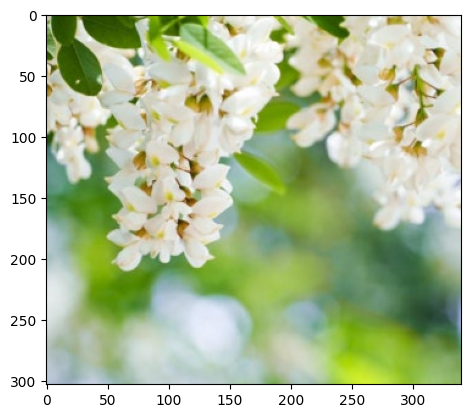

✅ 예측 결과: Freesia (99.96%)


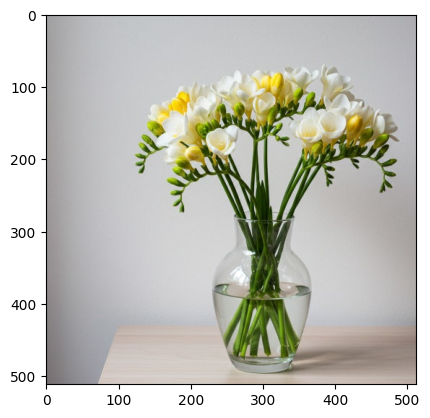

In [5]:
def predict_flower(image_path, model_path='flower30_resnet50_acacia.pth'):
    # 1. 모델 구조 준비 및 가중치 불러오기
    model = models.resnet50()
    model.fc = nn.Linear(model.fc.in_features, 30) # 클래스 수 30개 설정
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    # 2. 이미지 전처리 (학습 때와 동일하게!)
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    from PIL import Image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0) # 배치 차원 추가
    
    # 3. 추론 (Inference)
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        prob = torch.nn.functional.softmax(outputs, dim=1)
        
    print(f"✅ 예측 결과: {class_names[preds[0]]} ({prob[0][preds[0]]*100:.2f}%)")
    plt.imshow(img)
    plt.show()

# 테스트해보고 싶은 사진 경로를 넣어보세요!
predict_flower(r'C:\Users\한민규\Desktop\머신러닝 실습\아카시아.jpg')
predict_flower(r'C:\Users\한민규\Desktop\머신러닝 실습\프리지아.jpg')

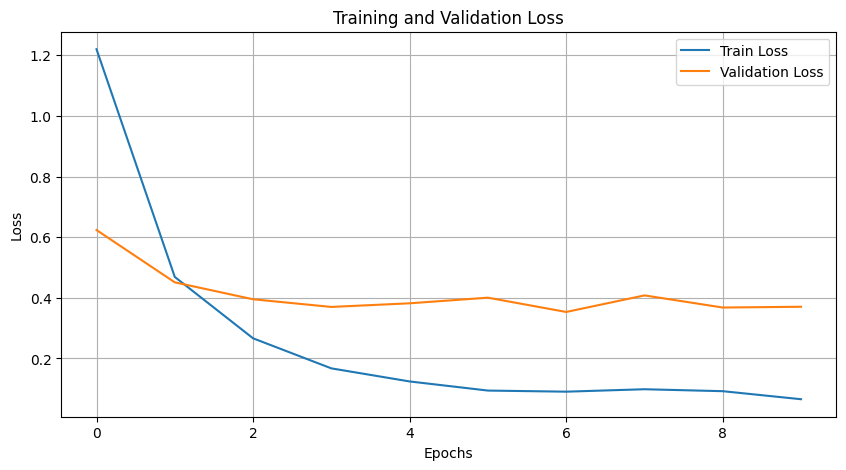

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()